
  NOISE EFFECT ANALYSIS
  Noise levels tested: [0.1, 0.5, 1.0, 2.0, 4.0]

  LINEAR REGRESSION  (statsmodels OLS)
  True β₀ = 5.0  |  True β₁ = 3.0
-----------------------------------------------------------------
  σ= 0.1  β₀= 4.985(±0.013)  β₁= 3.002(±0.002)  R²=0.9999
  σ= 0.5  β₀= 5.050(±0.070)  β₁= 2.999(±0.012)  R²=0.9968
  σ= 1.0  β₀= 4.930(±0.140)  β₁= 2.997(±0.024)  R²=0.9872
  σ= 2.0  β₀= 5.050(±0.288)  β₁= 2.993(±0.050)  R²=0.9480
  σ= 4.0  β₀= 6.039(±0.538)  β₁= 2.895(±0.093)  R²=0.8299

  Summary table:
 Noise σ  β₀ est  β₀ SE  β₁ est  β₁ SE     R²
     0.1   4.985  0.013   3.002  0.002 0.9999
     0.5   5.050  0.070   2.999  0.012 0.9968
     1.0   4.930  0.140   2.997  0.024 0.9872
     2.0   5.050  0.288   2.993  0.050 0.9480
     4.0   6.039  0.538   2.895  0.093 0.8299


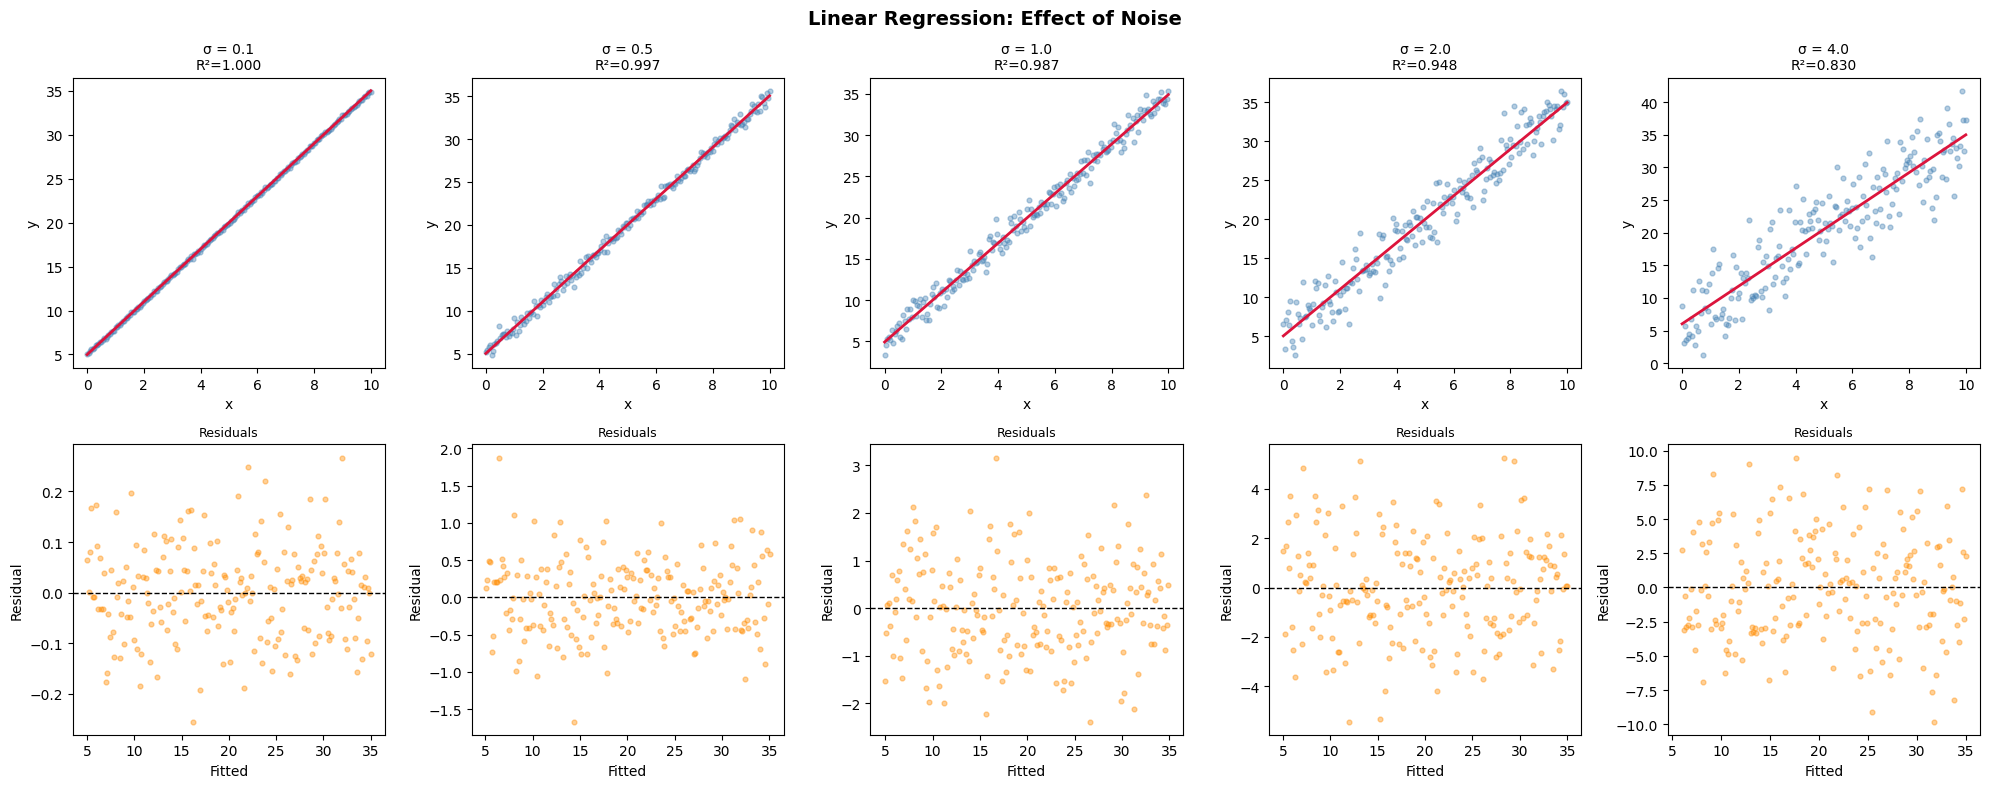

  [Plot saved: linear_regression_noise.png]

  CLASSIFICATION  (scikit-learn — RF + SVM)
  4 classes | 6 features | 4 informative | n=600
-----------------------------------------------------------------
  Noise σ= 0.1  |  RF acc=0.867  |  SVM acc=0.867
  -- RF --
              precision    recall  f1-score   support

          C0      0.867     0.886     0.876        44
          C1      0.886     0.689     0.775        45
          C2      0.788     0.911     0.845        45
          C3      0.938     0.978     0.957        46

    accuracy                          0.867       180
   macro avg      0.870     0.866     0.864       180
weighted avg      0.870     0.867     0.864       180

  Noise σ= 0.5  |  RF acc=0.783  |  SVM acc=0.811
  -- RF --
              precision    recall  f1-score   support

          C0      0.857     0.818     0.837        44
          C1      0.730     0.600     0.659        45
          C2      0.654     0.756     0.701        45
          C3      0.89

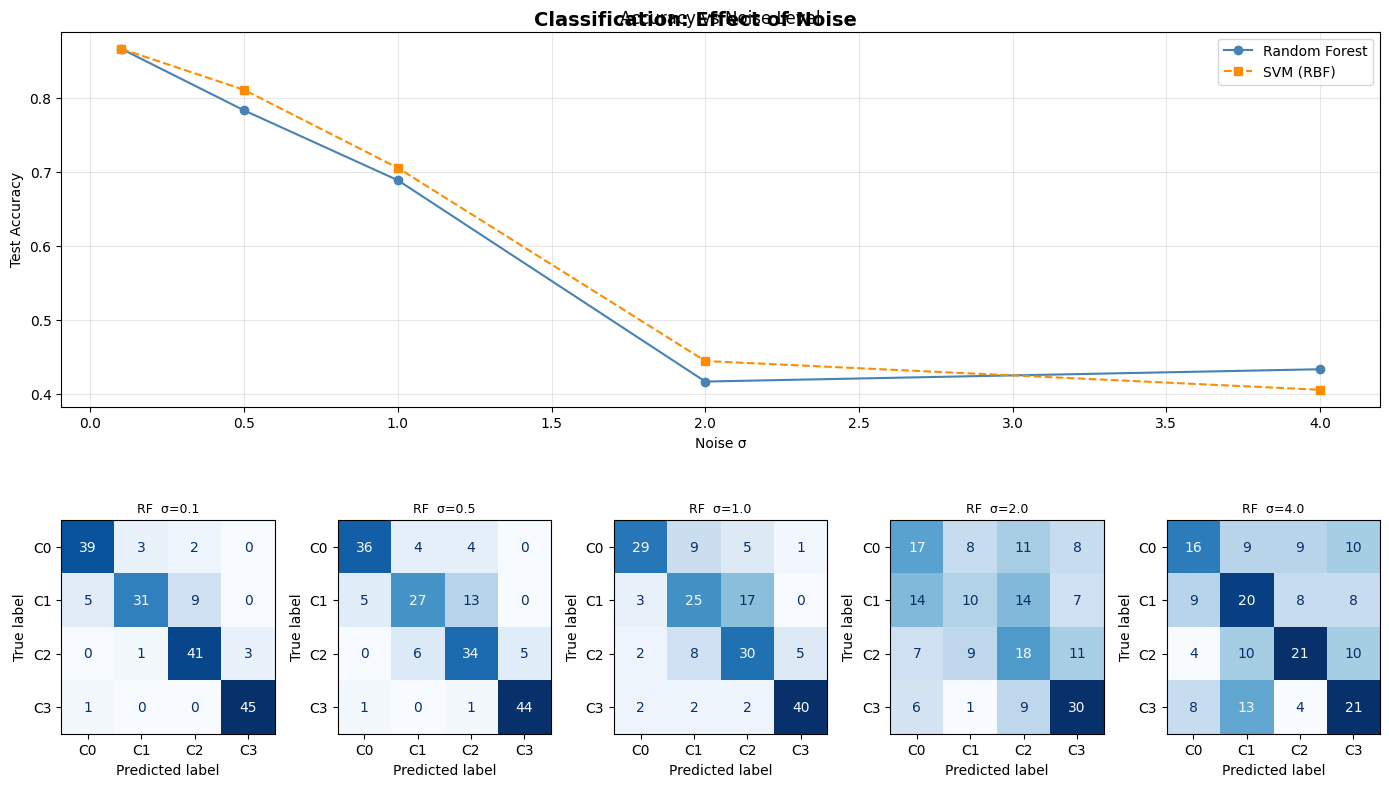

  [Plot saved: classification_noise.png]

  TIME SERIES FORECASTING  (statsmodels)
  n=200 | trend=0.3 | seasonal period=12 | horizon=24
-----------------------------------------------------------------
  σ= 0.1  |  SARIMAX RMSE=  0.134  AIC= -215.36  |  HW RMSE=  0.139
  σ= 0.5  |  SARIMAX RMSE=  0.638  AIC=  242.16  |  HW RMSE=  0.604
  σ= 1.0  |  SARIMAX RMSE=  1.381  AIC=  451.67  |  HW RMSE=  1.196
  σ= 2.0  |  SARIMAX RMSE=  1.987  AIC=  666.50  |  HW RMSE=  1.956
  σ= 4.0  |  SARIMAX RMSE=  4.395  AIC=  895.52  |  HW RMSE=  4.128


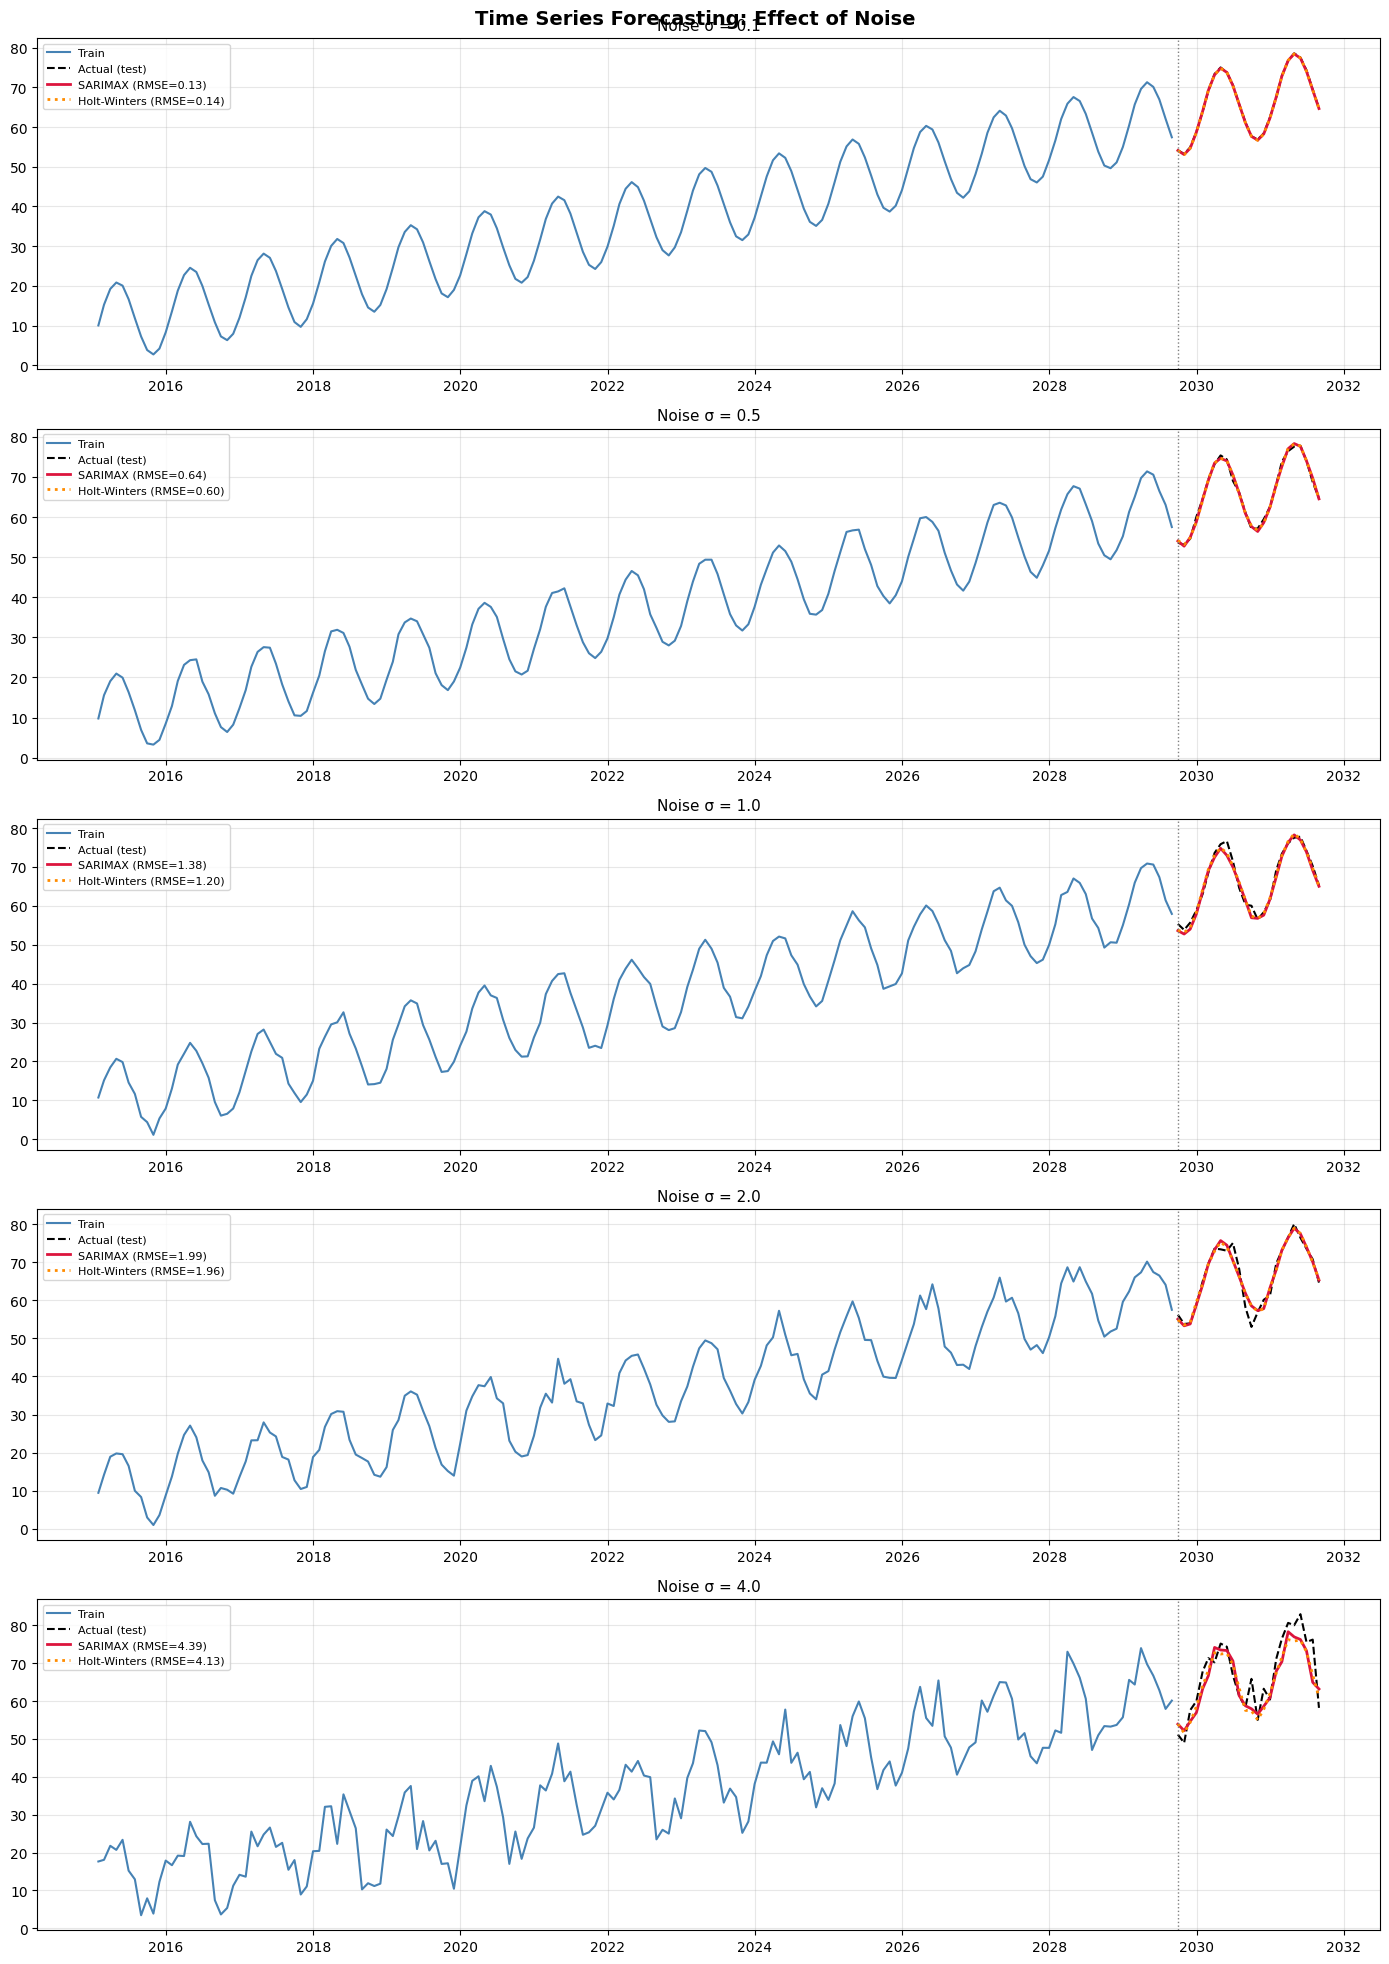

  [Plot saved: timeseries_noise.png]


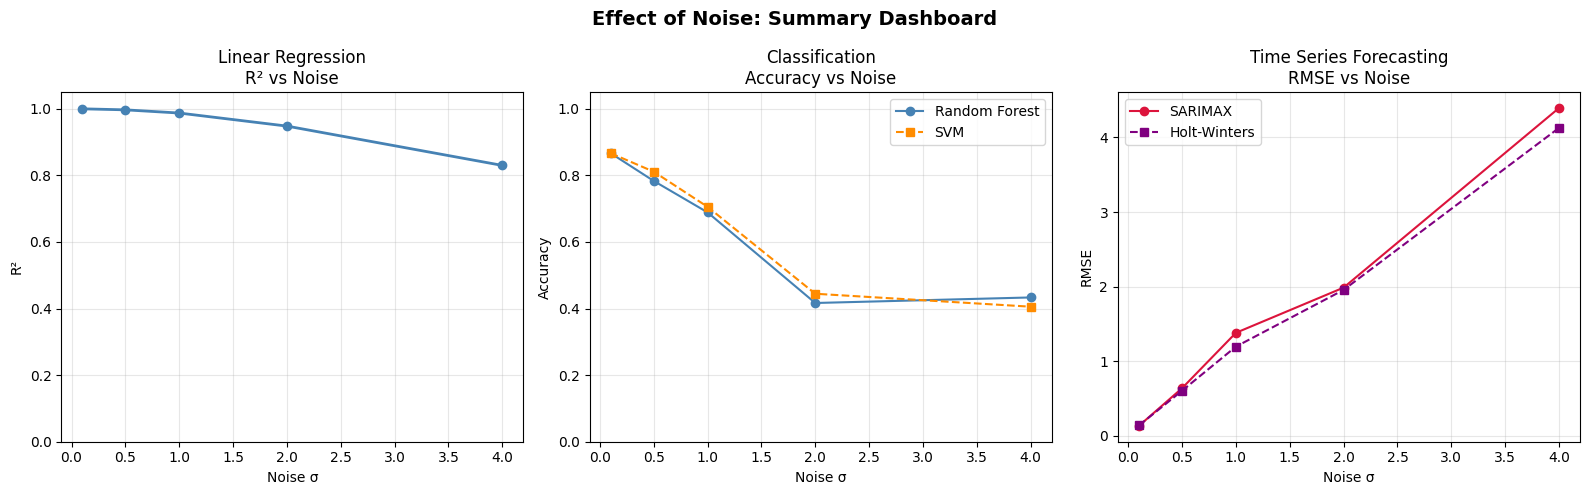

  [Plot saved: summary_dashboard.png]

  All done. Output plots saved to /mnt/user-data/outputs/


In [2]:
"""
=============================================================================
Effect of Noise on Parameter Estimation, Classification & Time Series
=============================================================================
Libraries:
  - Linear Regression   : statsmodels OLS
  - Classification      : scikit-learn (RandomForestClassifier + SVM)
  - Time Series         : statsmodels SARIMAX / ExponentialSmoothing
=============================================================================
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ── statsmodels ──────────────────────────────────────────────────────────────
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ── scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score
)


output_path = r"C:\Users\JayantiPrasad\OneDrive\Codes\python-ml-dl\noise-analysis\output"
# =============================================================================
# GLOBAL SETTINGS  – tweak these to add / reduce noise
# =============================================================================
NOISE_LEVELS = [0.1, 0.5, 1.0, 2.0, 4.0]   # σ multipliers for each dataset

# ── Linear data ──
LIN_N_SAMPLES   = 200          # number of observations
LIN_TRUE_SLOPE  = 3.0          # β₁
LIN_TRUE_INTER  = 5.0          # β₀

# ── Classification data ──
CLF_N_SAMPLES   = 600          # total observations
CLF_N_CLASSES   = 4
CLF_N_FEATURES  = 6            # total features
CLF_N_INFORM    = 4            # informative features

# ── Time-series data ──
TS_N_PERIODS    = 200          # number of time steps
TS_TREND        = 0.3          # slope of underlying trend
TS_SEASONAL_AMP = 10.0         # seasonal amplitude
TS_SEASONAL_PER = 12           # seasonal period (e.g. monthly)
TS_FORECAST_H   = 24           # forecast horizon

SEED = 42
np.random.seed(SEED)

# =============================================================================
# 1.  DATA GENERATORS
# =============================================================================

def generate_linear_data(n=LIN_N_SAMPLES,
                         slope=LIN_TRUE_SLOPE,
                         intercept=LIN_TRUE_INTER,
                         noise_std=1.0):
    """Generate y = intercept + slope·x + ε,  ε ~ N(0, noise_std²)."""
    x = np.linspace(0, 10, n)
    y = intercept + slope * x + np.random.normal(0, noise_std, n)
    return x, y


def generate_classification_data(n=CLF_N_SAMPLES,
                                  n_classes=CLF_N_CLASSES,
                                  n_features=CLF_N_FEATURES,
                                  n_informative=CLF_N_INFORM,
                                  noise_level=0.0):
    """
    4-class classification data via sklearn make_classification.
    noise_level adds Gaussian noise to every feature column.
    """
    X, y = make_classification(
        n_samples=n,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=1,
        n_repeated=0,
        n_classes=n_classes,
        n_clusters_per_class=1,
        random_state=SEED
    )
    if noise_level > 0:
        X = X + np.random.normal(0, noise_level, X.shape)
    return X, y


def generate_timeseries_data(n=TS_N_PERIODS,
                              trend=TS_TREND,
                              seasonal_amp=TS_SEASONAL_AMP,
                              seasonal_period=TS_SEASONAL_PER,
                              noise_std=1.0):
    """
    Additive time series:  y(t) = trend·t + seasonal_amp·sin(2π t/period) + ε
    """
    t = np.arange(n)
    seasonal = seasonal_amp * np.sin(2 * np.pi * t / seasonal_period)
    trend_c  = trend * t
    noise    = np.random.normal(0, noise_std, n)
    y        = 10 + trend_c + seasonal + noise
    dates    = pd.date_range("2015-01", periods=n, freq="ME")
    return pd.Series(y, index=dates)


# =============================================================================
# 2.  LINEAR REGRESSION  (statsmodels OLS)
# =============================================================================

def run_linear_regression(noise_levels=None, plot=True):
    """
    Fit OLS for each noise level and report coefficient estimates,
    standard errors, R², and confidence intervals.
    """
    if noise_levels is None:
        noise_levels = NOISE_LEVELS

    print("\n" + "="*65)
    print("  LINEAR REGRESSION  (statsmodels OLS)")
    print("="*65)
    print(f"  True β₀ = {LIN_TRUE_INTER}  |  True β₁ = {LIN_TRUE_SLOPE}")
    print("-"*65)

    records = []
    models  = {}

    for σ in noise_levels:
        x, y = generate_linear_data(noise_std=σ)
        X    = sm.add_constant(x)
        res  = sm.OLS(y, X).fit()

        b0, b1   = res.params
        se0, se1 = res.bse
        ci       = res.conf_int()
        r2       = res.rsquared

        records.append({
            "Noise σ": σ,
            "β₀ est": round(b0, 3), "β₀ SE": round(se0, 3),
            "β₁ est": round(b1, 3), "β₁ SE": round(se1, 3),
            "R²": round(r2, 4)
        })
        models[σ] = (x, y, res)
        print(f"  σ={σ:4.1f}  β₀={b0:6.3f}(±{se0:.3f})  "
              f"β₁={b1:6.3f}(±{se1:.3f})  R²={r2:.4f}")

    df_results = pd.DataFrame(records)
    print("\n  Summary table:")
    print(df_results.to_string(index=False))

    if plot:
        _plot_linear(models, noise_levels)

    return df_results, models


def _plot_linear(models, noise_levels):
    n = len(noise_levels)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    fig.suptitle("Linear Regression: Effect of Noise", fontsize=14, fontweight="bold")

    for col, σ in enumerate(noise_levels):
        x, y, res = models[σ]
        ax_scatter = axes[0, col]
        ax_resid   = axes[1, col]

        # — scatter + fit line
        ax_scatter.scatter(x, y, alpha=0.4, s=12, color="steelblue")
        x_pred = np.linspace(x.min(), x.max(), 200)
        ax_scatter.plot(x_pred, res.params[0] + res.params[1]*x_pred,
                        color="crimson", lw=2)
        ax_scatter.set_title(f"σ = {σ}\nR²={res.rsquared:.3f}", fontsize=10)
        ax_scatter.set_xlabel("x"); ax_scatter.set_ylabel("y")

        # — residual plot
        fitted = res.fittedvalues
        resid  = res.resid
        ax_resid.scatter(fitted, resid, alpha=0.4, s=12, color="darkorange")
        ax_resid.axhline(0, color="black", lw=1, linestyle="--")
        ax_resid.set_title("Residuals", fontsize=9)
        ax_resid.set_xlabel("Fitted"); ax_resid.set_ylabel("Residual")

    plt.tight_layout()
    plt.savefig(output_path + os.sep + "linear_regression_noise.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("  [Plot saved: linear_regression_noise.png]")


# =============================================================================
# 3.  CLASSIFICATION  (scikit-learn)
# =============================================================================

def run_classification(noise_levels=None, plot=True):
    """
    Train RandomForestClassifier and SVM at each noise level.
    Report accuracy, classification report, confusion matrix.
    """
    if noise_levels is None:
        noise_levels = NOISE_LEVELS

    print("\n" + "="*65)
    print("  CLASSIFICATION  (scikit-learn — RF + SVM)")
    print("="*65)
    print(f"  {CLF_N_CLASSES} classes | {CLF_N_FEATURES} features "
          f"| {CLF_N_INFORM} informative | n={CLF_N_SAMPLES}")
    print("-"*65)

    rf_acc_list, svm_acc_list = [], []

    all_models = {}

    for σ in noise_levels:
        X, y = generate_classification_data(noise_level=σ)
        scaler = StandardScaler()
        X_s    = scaler.fit_transform(X)

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_s, y, test_size=0.3, random_state=SEED, stratify=y
        )

        # — Random Forest
        rf  = RandomForestClassifier(n_estimators=100, random_state=SEED)
        rf.fit(X_tr, y_tr)
        rf_pred = rf.predict(X_te)
        rf_acc  = accuracy_score(y_te, rf_pred)

        # — SVM
        svm = SVC(kernel="rbf", C=1.0, random_state=SEED)
        svm.fit(X_tr, y_tr)
        svm_pred = svm.predict(X_te)
        svm_acc  = accuracy_score(y_te, svm_pred)

        rf_acc_list.append(rf_acc)
        svm_acc_list.append(svm_acc)
        all_models[σ] = (y_te, rf_pred, svm_pred)

        print(f"  Noise σ={σ:4.1f}  |  RF acc={rf_acc:.3f}  |  SVM acc={svm_acc:.3f}")
        print("  -- RF --")
        print(classification_report(y_te, rf_pred, digits=3,
                                    target_names=[f"C{i}" for i in range(CLF_N_CLASSES)]))

    if plot:
        _plot_classification(noise_levels, rf_acc_list, svm_acc_list, all_models)

    return noise_levels, rf_acc_list, svm_acc_list


def _plot_classification(noise_levels, rf_acc, svm_acc, all_models):
    fig = plt.figure(figsize=(14, 5 + 4*len(noise_levels)))
    fig.suptitle("Classification: Effect of Noise", fontsize=14, fontweight="bold")

    # — accuracy vs noise
    ax_acc = fig.add_subplot(1 + len(noise_levels), 1, 1)
    ax_acc.plot(noise_levels, rf_acc,  "o-", label="Random Forest", color="steelblue")
    ax_acc.plot(noise_levels, svm_acc, "s--", label="SVM (RBF)",   color="darkorange")
    ax_acc.set_xlabel("Noise σ"); ax_acc.set_ylabel("Test Accuracy")
    ax_acc.set_title("Accuracy vs Noise Level"); ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    # — confusion matrices for RF at each noise level
    for i, σ in enumerate(noise_levels):
        y_te, rf_pred, _ = all_models[σ]
        ax = fig.add_subplot(1 + len(noise_levels), len(noise_levels), len(noise_levels) + 1 + i)
        cm  = confusion_matrix(y_te, rf_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=[f"C{j}" for j in range(CLF_N_CLASSES)])
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"RF  σ={σ}", fontsize=9)

    plt.tight_layout()
    plt.savefig(output_path + os.sep + "classification_noise.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("  [Plot saved: classification_noise.png]")


# =============================================================================
# 4.  TIME SERIES FORECASTING  (statsmodels SARIMAX + Holt-Winters)
# =============================================================================

def run_timeseries(noise_levels=None, plot=True):
    """
    Fit SARIMAX(1,1,1)(1,1,1,12) + Holt-Winters for each noise level.
    Report AIC, BIC, RMSE.
    """
    if noise_levels is None:
        noise_levels = NOISE_LEVELS

    print("\n" + "="*65)
    print("  TIME SERIES FORECASTING  (statsmodels)")
    print("="*65)
    print(f"  n={TS_N_PERIODS} | trend={TS_TREND} | "
          f"seasonal period={TS_SEASONAL_PER} | horizon={TS_FORECAST_H}")
    print("-"*65)

    results = {}

    for σ in noise_levels:
        ts = generate_timeseries_data(noise_std=σ)
        train = ts.iloc[:-TS_FORECAST_H]
        test  = ts.iloc[-TS_FORECAST_H:]

        # ── SARIMAX ──────────────────────────────────────────────────────────
        try:
            sarima_res = SARIMAX(
                train,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, TS_SEASONAL_PER),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            sarima_fc   = sarima_res.forecast(steps=TS_FORECAST_H)
            sarima_rmse = np.sqrt(np.mean((test.values - sarima_fc.values)**2))
            sarima_aic  = round(sarima_res.aic, 2)
        except Exception as e:
            print(f"    SARIMAX failed for σ={σ}: {e}")
            sarima_fc, sarima_rmse, sarima_aic = None, np.nan, np.nan

        # ── Holt-Winters ─────────────────────────────────────────────────────
        try:
            hw_res  = ExponentialSmoothing(
                train,
                trend="add",
                seasonal="add",
                seasonal_periods=TS_SEASONAL_PER
            ).fit()
            hw_fc   = hw_res.forecast(TS_FORECAST_H)
            hw_rmse = np.sqrt(np.mean((test.values - hw_fc.values)**2))
        except Exception as e:
            print(f"    Holt-Winters failed for σ={σ}: {e}")
            hw_fc, hw_rmse = None, np.nan

        results[σ] = {
            "ts": ts, "train": train, "test": test,
            "sarima_fc": sarima_fc, "sarima_rmse": sarima_rmse, "sarima_aic": sarima_aic,
            "hw_fc": hw_fc,         "hw_rmse": hw_rmse
        }

        print(f"  σ={σ:4.1f}  |  SARIMAX RMSE={sarima_rmse:7.3f}  AIC={sarima_aic:8.2f}"
              f"  |  HW RMSE={hw_rmse:7.3f}")

    if plot:
        _plot_timeseries(noise_levels, results)

    return results


def _plot_timeseries(noise_levels, results):
    n = len(noise_levels)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4*n), sharex=False)
    if n == 1:
        axes = [axes]
    fig.suptitle("Time Series Forecasting: Effect of Noise", fontsize=14, fontweight="bold")

    for ax, σ in zip(axes, noise_levels):
        r = results[σ]
        ax.plot(r["train"].index, r["train"].values,
                color="steelblue", lw=1.5, label="Train")
        ax.plot(r["test"].index, r["test"].values,
                color="black",     lw=1.5, linestyle="--", label="Actual (test)")

        if r["sarima_fc"] is not None:
            ax.plot(r["test"].index, r["sarima_fc"].values,
                    color="crimson", lw=2, label=f"SARIMAX (RMSE={r['sarima_rmse']:.2f})")
        if r["hw_fc"] is not None:
            ax.plot(r["test"].index, r["hw_fc"].values,
                    color="darkorange", lw=2, linestyle=":", label=f"Holt-Winters (RMSE={r['hw_rmse']:.2f})")

        ax.axvline(r["test"].index[0], color="gray", linestyle=":", lw=1)
        ax.set_title(f"Noise σ = {σ}", fontsize=11)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path + os.sep + "timeseries_noise.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("  [Plot saved: timeseries_noise.png]")


# =============================================================================
# 5.  SUMMARY DASHBOARD
# =============================================================================

def plot_summary_dashboard(lin_df, clf_data, ts_results):
    """Single figure summarising all three tasks across noise levels."""
    noise_levels, rf_acc, svm_acc = clf_data

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Effect of Noise: Summary Dashboard", fontsize=14, fontweight="bold")

    # ── Panel 1: Linear — R² vs noise ─────────────────────────────────────
    ax = axes[0]
    ax.plot(lin_df["Noise σ"], lin_df["R²"], "o-", color="steelblue", lw=2)
    ax.set_xlabel("Noise σ"); ax.set_ylabel("R²")
    ax.set_title("Linear Regression\nR² vs Noise"); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

    # ── Panel 2: Classification — accuracy vs noise ────────────────────────
    ax = axes[1]
    ax.plot(noise_levels, rf_acc,  "o-",  label="Random Forest", color="steelblue")
    ax.plot(noise_levels, svm_acc, "s--", label="SVM",           color="darkorange")
    ax.set_xlabel("Noise σ"); ax.set_ylabel("Accuracy")
    ax.set_title("Classification\nAccuracy vs Noise")
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)

    # ── Panel 3: Time Series — RMSE vs noise ──────────────────────────────
    ax = axes[2]
    sarima_rmse = [ts_results[σ]["sarima_rmse"] for σ in noise_levels]
    hw_rmse     = [ts_results[σ]["hw_rmse"]     for σ in noise_levels]
    ax.plot(noise_levels, sarima_rmse, "o-",  label="SARIMAX",      color="crimson")
    ax.plot(noise_levels, hw_rmse,     "s--", label="Holt-Winters",  color="purple")
    ax.set_xlabel("Noise σ"); ax.set_ylabel("RMSE")
    ax.set_title("Time Series Forecasting\nRMSE vs Noise")
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path + os.sep + "summary_dashboard.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("  [Plot saved: summary_dashboard.png]")


# =============================================================================
# 6.  MAIN
# =============================================================================

if __name__ == "__main__":
    # ── You can change NOISE_LEVELS at the top to explore more / fewer levels
    print("\n" + "="*65)
    print("  NOISE EFFECT ANALYSIS")
    print(f"  Noise levels tested: {NOISE_LEVELS}")
    print("="*65)

    # 1. Linear regression
    lin_df, lin_models = run_linear_regression(noise_levels=NOISE_LEVELS)

    # 2. Classification
    clf_data = run_classification(noise_levels=NOISE_LEVELS)

    # 3. Time series
    ts_results = run_timeseries(noise_levels=NOISE_LEVELS)

    # 4. Summary dashboard
    plot_summary_dashboard(lin_df, clf_data, ts_results)

    print("\n  All done. Output plots saved to /mnt/user-data/outputs/")